# Analysis: Matrix Condition (Experiment 4)
## Disentangling Observation and Reward Components of Empathy

This notebook implements the analysis plan from `prereg_matrix_condition.md`.

**Design**: 2x2 factorial (see_emotions x alpha)
- A: blind_non_empathic (False, 0.0) — baseline
- B: blind_reward_empathic (False, 0.5)
- C: sees_ignores (True, 0.0)
- D: full_empathy (True, 0.5)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os
import re
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, ttest_ind
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Helper Functions
Reused from `jerome_analysis_first.ipynb`

In [2]:
# --- Gini coefficient ---

def gini_coefficient(arr: np.ndarray) -> float:
    """Compute Gini coefficient of a 1D numpy array."""
    arr = arr.flatten()
    if np.amin(arr) < 0:
        arr = arr - np.amin(arr)
    mean = np.mean(arr)
    if mean == 0:
        return 0.0
    n = len(arr)
    diff_sum = np.sum(np.abs(np.subtract.outer(arr, arr)))
    gini = diff_sum / (2 * n**2 * mean)
    return gini


def parse_value(val):
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple, np.ndarray)):
                return np.array(parsed, dtype=float)
            else:
                return float(parsed)
        except (ValueError, SyntaxError):
            return float(val)
    elif isinstance(val, (list, tuple, np.ndarray)):
        return np.array(val, dtype=float)
    else:
        return float(val)


def compute_gini_for_df(df: pd.DataFrame, prefix: str) -> pd.Series:
    """Compute Gini coefficient across columns starting with prefix for each row."""
    cols = [col for col in df.columns if col.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found starting with prefix '{prefix}'")

    def row_gini(row):
        values = []
        for val in row.values:
            parsed_val = parse_value(val)
            if isinstance(parsed_val, np.ndarray):
                values.extend(parsed_val.flatten())
            else:
                values.append(parsed_val)
        values = np.array(values, dtype=float)
        return gini_coefficient(values)

    return df[cols].apply(row_gini, axis=1)

In [3]:
# --- Efficiency ---

def compute_efficiency_for_df(df: pd.DataFrame, prefix: str, new_column_name: str) -> pd.DataFrame:
    """Compute the average across columns starting with a given prefix for each row."""
    cols = [col for col in df.columns if col.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found starting with prefix '{prefix}'")

    for col in cols:
        def parse_cell(val):
            if isinstance(val, (float, int)):
                return float(val)
            if isinstance(val, str):
                try:
                    parsed = ast.literal_eval(val)
                    if isinstance(parsed, list) and len(parsed) == 1:
                        return float(parsed[0])
                    return float(parsed)
                except Exception:
                    raise ValueError(f"Value '{val}' in column '{col}' could not be parsed to float.")
            raise ValueError(f"Unsupported value type {type(val)} in column '{col}'.")
        df[col] = df[col].apply(parse_cell)

    df[new_column_name] = df[cols].mean(axis=1)
    return df

In [4]:
# --- Resource depletion ---

def _clean_initial_resources_column(df: pd.DataFrame, col_name: str) -> None:
    def extract_number(x):
        if pd.isna(x):
            return np.nan
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list, tuple)) and len(parsed) > 0:
                return float(parsed[0])
            else:
                return np.nan
        except:
            return np.nan

    if col_name in df.columns and df[col_name].dtype == object:
        df[col_name] = df[col_name].apply(extract_number)
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')


def GT_compute_depletion_from_summary(df: pd.DataFrame) -> None:
    _clean_initial_resources_column(df, 'initial_resources')
    df.loc[:, 'depletion_final'] = 1 - df['resource_remaining'] / df['initial_resources']
    df.loc[:, 'depletion_early'] = 1 - df['total_steps'] / df['max_steps']

In [5]:
# --- Learning curve visualization ---

def windowed_avg_combined_reward(
    df: pd.DataFrame,
    reward_prefix: str = "total_combined_reward_",
    episode_column: str = "episode",
    simulation_id_column: str = "simulation_index",
    window_size: int = 5,
    aggregation_mode: str = "mean",
    plot: bool = False
) -> pd.DataFrame:
    reward_cols = [col for col in df.columns if col.startswith(reward_prefix)]
    if not reward_cols:
        raise ValueError(f"No columns found with prefix '{reward_prefix}'")

    df = df.copy()
    if aggregation_mode == "mean":
        df["aggregated_reward"] = df[reward_cols].mean(axis=1)
    elif aggregation_mode == "best":
        df["aggregated_reward"] = df[reward_cols].max(axis=1)
    else:
        raise ValueError("aggregation_mode must be 'mean' or 'best'")

    episode_avg = (
        df.groupby(episode_column)["aggregated_reward"]
        .mean()
        .reset_index()
        .rename(columns={"aggregated_reward": "mean_reward"})
    )
    episode_avg["moving_avg"] = (
        episode_avg["mean_reward"].rolling(window=window_size, min_periods=1, center=True).mean()
    )

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(episode_avg[episode_column], episode_avg["moving_avg"], label=f"Moving Avg ({aggregation_mode})")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.title(f"{aggregation_mode.capitalize()} Agent Reward (Window={window_size})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return episode_avg

In [6]:
# --- Mean and range plot ---

def plot_mean_and_range_across_simulations(
    df: pd.DataFrame,
    value_col: str,
    simulation_col: str = 'seed',
    episode_col: str = 'episode',
    step_col: str = 'step',
    is_step_csv: bool = False,
    title: str = None,
    ylabel: str = None,
    rolling_window: int = None,
    plot_individual: bool = False
):
    if is_step_csv:
        group_cols = [simulation_col, episode_col, step_col]
        avg_group_cols = [episode_col, step_col]
    else:
        group_cols = [simulation_col, episode_col]
        avg_group_cols = [episode_col]

    sim_stats = df.groupby(group_cols)[value_col].mean().reset_index()
    agg_funcs = {value_col: ['mean', 'min', 'max']}
    summary = sim_stats.groupby(avg_group_cols).agg(agg_funcs)
    summary.columns = ['mean', 'min', 'max']
    summary = summary.reset_index()

    if rolling_window and rolling_window > 1:
        summary['mean'] = summary['mean'].rolling(rolling_window, min_periods=1, center=True).mean()
        summary['min'] = summary['min'].rolling(rolling_window, min_periods=1, center=True).mean()
        summary['max'] = summary['max'].rolling(rolling_window, min_periods=1, center=True).mean()

    plt.figure(figsize=(10, 6))
    if plot_individual:
        for sim_id, sim_df in sim_stats.groupby(simulation_col):
            x = sim_df[episode_col] if not is_step_csv else sim_df[step_col]
            y = sim_df[value_col]
            if rolling_window:
                y = y.rolling(rolling_window, min_periods=1).mean()
            plt.plot(x, y, color='gray', alpha=0.3, label=f"Sim {sim_id}")

    x_vals = summary[episode_col] if not is_step_csv else summary[step_col]
    plt.fill_between(x_vals, summary['min'], summary['max'], color='blue', alpha=0.2, label='Range (min-max)')
    plt.plot(x_vals, summary['mean'], color='blue', linewidth=2, label='Mean')
    plt.xlabel('Episode' if not is_step_csv else 'Step')
    plt.ylabel(ylabel if ylabel else value_col)
    plt.title(title or f"Fluctuation of {value_col} with range")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 3. Data Loading

In [7]:
# Filename regex for DQN game-theoretic results
FILENAME_PATTERN = re.compile(
    r"results_(?P<simulation_index>\d{3})_(?P<episodes>\d+)_DQN_"
    r"(?P<emotion>[^_]+)_(?P<see_emotions>[^_]+)_"
    r"(?P<alpha>[\d.]+)_(?P<beta>[\d.]+)_(?P<smoothing>[^_]+)_(?P<threshold>[\d.]+)_(?P<rounder>[\d.]+)_"
    r"(?P<learning_rate>[\d.]+)_(?P<gamma>[\d.]+)_(?P<epsilon>[\d.]+)_(?P<epsilon_decay>[\d.]+)_(?P<epsilon_min>[\d.]+)_"
    r"(?P<batch_size>[\d.]+)_(?P<hidden_size>[\d.]+)_(?P<update_target_every>[\d.]+)_"
    r"(?P<random_suffix>\d{6})_(?P<suffix>[a-zA-Z]+_[a-zA-Z]+)\.csv"
)

DATA_DIR = os.path.join('game_theoretic_matrix_setup', 'results')

# Condition mapping
def assign_condition(see_emotions, alpha):
    see = str(see_emotions).strip().lower() == 'true'
    a = float(alpha)
    if not see and a == 0.0:
        return 'A'
    elif not see and a == 0.5:
        return 'B'
    elif see and a == 0.0:
        return 'C'
    elif see and a == 0.5:
        return 'D'
    else:
        return 'Unknown'

CONDITION_LABELS = {
    'A': 'blind_non_empathic',
    'B': 'blind_reward_empathic',
    'C': 'sees_ignores',
    'D': 'full_empathy'
}

# Load and tag all episode_summary CSVs
all_dfs = []
for filename in sorted(os.listdir(DATA_DIR)):
    if not filename.endswith('.csv'):
        continue
    match = FILENAME_PATTERN.match(filename)
    if match and match.group('suffix') == 'episode_summary':
        meta = match.groupdict()
        filepath = os.path.join(DATA_DIR, filename)
        df_tmp = pd.read_csv(filepath)
        df_tmp['alpha'] = float(meta['alpha'])
        df_tmp['see_emotions'] = meta['see_emotions']
        df_tmp['run_id'] = int(meta['simulation_index'])
        df_tmp['condition'] = assign_condition(meta['see_emotions'], meta['alpha'])
        df_tmp['condition_label'] = df_tmp['condition'].map(CONDITION_LABELS)
        all_dfs.append(df_tmp)

df = pd.concat(all_dfs, ignore_index=True)
print(f"Loaded {len(all_dfs)} files, {len(df)} total rows")
print(f"\nCondition counts:")
print(df.groupby(['condition', 'condition_label', 'see_emotions', 'alpha'])['run_id'].nunique().reset_index().rename(columns={'run_id': 'n_runs'}).to_string(index=False))

Loaded 24 files, 12037 total rows

Condition counts:
condition       condition_label see_emotions  alpha  n_runs
        A    blind_non_empathic        False    0.0       3
        B blind_reward_empathic        False    0.5       3
        C          sees_ignores         True    0.0       3
        D          full_empathy         True    0.5       3


## 4. Dependent Variable Computation

In [8]:
# Depletion
GT_compute_depletion_from_summary(df)

# Gini coefficient on personal rewards
df['gini_personal_reward'] = compute_gini_for_df(df, prefix='total_personal_reward_')

# Efficiency (exploratory)
compute_efficiency_for_df(df, prefix='total_personal_reward_', new_column_name='efficiency')

print("DVs computed successfully.")
print(df[['condition', 'total_steps', 'depletion_final', 'gini_personal_reward', 'efficiency']].groupby('condition').describe().round(3))

DVs computed successfully.
          total_steps                                                         \
                count     mean      std    min    25%    50%     75%     max   
condition                                                                      
A              3037.0  596.634  112.602  341.0  516.0  580.0   658.0  1000.0   
B              3000.0  814.359  166.026  391.0  680.0  834.0  1000.0  1000.0   
C              3000.0  725.675  149.420  383.0  613.0  708.0   830.0  1000.0   
D              3000.0  811.110  172.810  382.0  662.0  830.5  1000.0  1000.0   

          depletion_final         ... gini_personal_reward        efficiency  \
                    count   mean  ...                  75%    max      count   
condition                         ...                                          
A                  3037.0  1.000  ...                0.055  0.126     3037.0   
B                  3000.0  0.999  ...                0.476  0.635     3000.0   
C           

## 5. Descriptive Statistics

In [9]:
# Summary table: mean +/- SD per condition
primary_dvs = ['depletion_final', 'total_steps', 'gini_personal_reward']
conditions = ['A', 'B', 'C', 'D']

desc_rows = []
for cond in conditions:
    subset = df[df['condition'] == cond]
    row = {'condition': cond, 'label': CONDITION_LABELS[cond]}
    for dv in primary_dvs:
        row[f'{dv}_mean'] = subset[dv].mean()
        row[f'{dv}_sd'] = subset[dv].std()
    desc_rows.append(row)

desc_df = pd.DataFrame(desc_rows)
print(desc_df.to_string(index=False))

condition                 label  depletion_final_mean  depletion_final_sd  total_steps_mean  total_steps_sd  gini_personal_reward_mean  gini_personal_reward_sd
        A    blind_non_empathic              0.999982            0.000201        596.633849      112.602415                   0.045384                 0.018225
        B blind_reward_empathic              0.999167            0.001763        814.359000      166.026085                   0.329295                 0.145554
        C          sees_ignores              0.999795            0.000752        725.675333      149.420211                   0.113747                 0.063849
        D          full_empathy              0.998683            0.003454        811.110000      172.810416                   0.190678                 0.085732


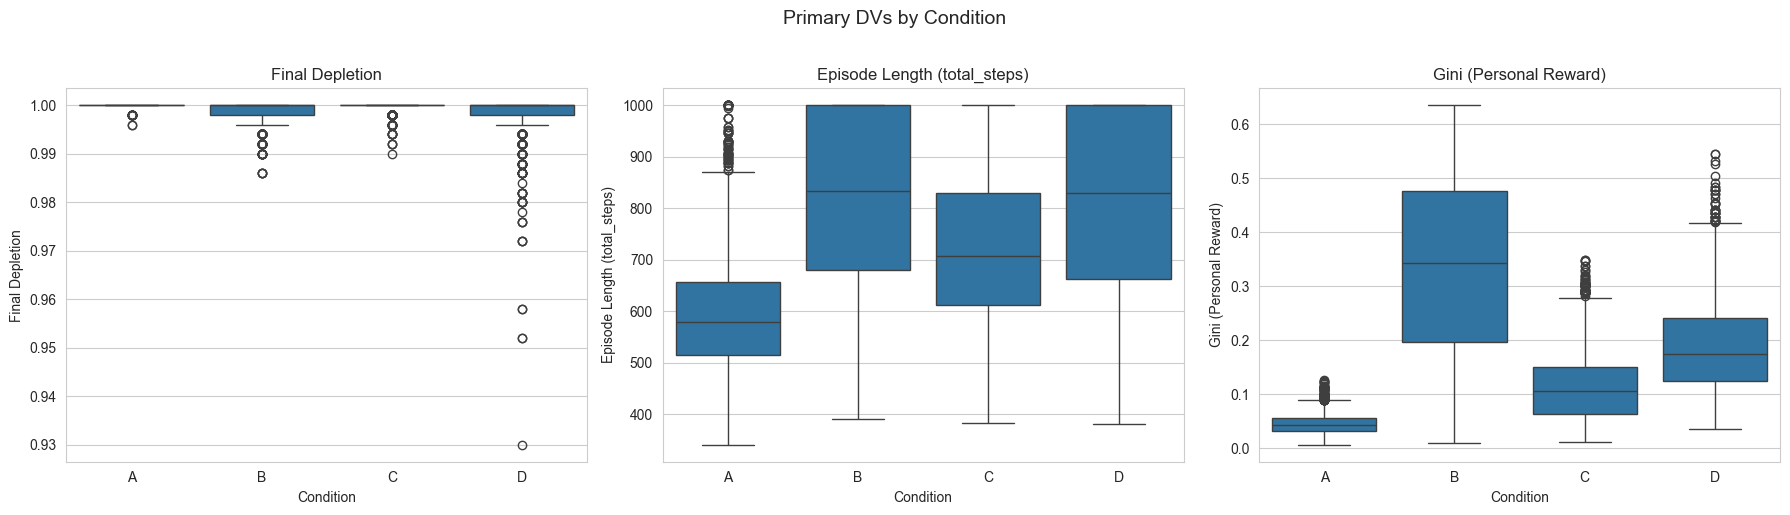

In [10]:
# Boxplots per condition for each DV
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dv_labels = ['Final Depletion', 'Episode Length (total_steps)', 'Gini (Personal Reward)']
condition_order = ['A', 'B', 'C', 'D']

for ax, dv, label in zip(axes, primary_dvs, dv_labels):
    sns.boxplot(data=df, x='condition', y=dv, order=condition_order, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Condition')
    ax.set_ylabel(label)

plt.suptitle('Primary DVs by Condition', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

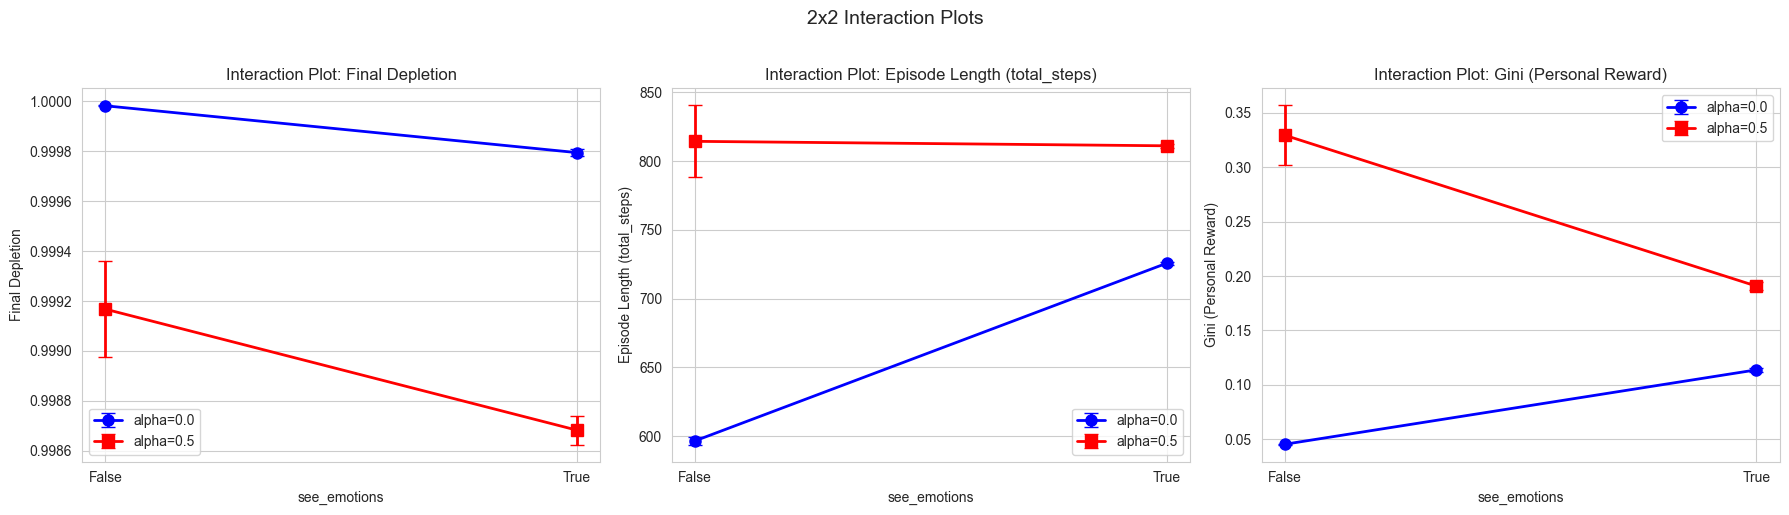

In [11]:
# 2x2 Interaction plot
run_means = df.groupby(['condition', 'see_emotions', 'alpha', 'run_id'])[primary_dvs].mean().reset_index()

# Convert see_emotions to boolean for plotting
run_means['see_emotions_bool'] = run_means['see_emotions'].apply(lambda x: str(x).strip().lower() == 'true')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, dv, label in zip(axes, primary_dvs, dv_labels):
    for alpha_val, marker, color in [(0.0, 'o', 'blue'), (0.5, 's', 'red')]:
        subset = run_means[run_means['alpha'] == alpha_val]
        means = subset.groupby('see_emotions_bool')[dv].mean()
        sds = subset.groupby('see_emotions_bool')[dv].std()
        x_pos = [0, 1]
        ax.errorbar(x_pos, means.values, yerr=sds.values, marker=marker, color=color,
                    label=f'alpha={alpha_val}', capsize=5, linewidth=2, markersize=8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['False', 'True'])
    ax.set_xlabel('see_emotions')
    ax.set_ylabel(label)
    ax.set_title(f'Interaction Plot: {label}')
    ax.legend()
    ax.grid(True)

plt.suptitle('2x2 Interaction Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. H1 — Reward Effect: B > A (Confirmatory)

**Hypothesis**: Empathic reward alone (B: alpha=0.5, see_emotions=False) improves resource preservation vs. baseline (A: alpha=0.0, see_emotions=False).

Tests: One-sided Mann-Whitney U + t-test. Bonferroni correction: 4 contrasts, alpha=0.0125.

In [12]:
bonferroni_alpha = 0.05 / 4  # 4 planned contrasts

def run_contrast(run_means, cond1, cond2, dv, direction='greater', label=''):
    """
    Run one-sided Mann-Whitney U and t-test comparing cond1 vs cond2.
    direction: 'greater' means cond1 > cond2, 'less' means cond1 < cond2.
    """
    g1 = run_means[run_means['condition'] == cond1][dv].values
    g2 = run_means[run_means['condition'] == cond2][dv].values

    U, p_mw = mannwhitneyu(g1, g2, alternative=direction)
    t, p_tt = ttest_ind(g1, g2, alternative=direction)

    sig_mw = '*' if p_mw < bonferroni_alpha else 'ns'
    sig_tt = '*' if p_tt < bonferroni_alpha else 'ns'

    print(f"  {label}:")
    print(f"    Mann-Whitney U: U={U:.1f}, p={p_mw:.6f} [{sig_mw}]")
    print(f"    t-test: t={t:.3f}, p={p_tt:.6f} [{sig_tt}]")
    print(f"    {cond1} mean={g1.mean():.4f}, {cond2} mean={g2.mean():.4f}, diff={g1.mean()-g2.mean():+.4f}")

    return {'contrast': label, 'DV': dv, 'U': U, 'p_MW': p_mw, 't': t, 'p_tt': p_tt,
            'mean_1': g1.mean(), 'mean_2': g2.mean()}


print("=" * 70)
print("H1: REWARD EFFECT (B > A)")
print(f"Bonferroni-corrected alpha = {bonferroni_alpha}")
print("=" * 70)

h1_results = []
for dv in primary_dvs:
    print(f"\n--- {dv} ---")
    if 'depletion' in dv:
        direction = 'less'  # B should have LESS depletion than A
    else:
        direction = 'greater'  # B should have MORE steps than A
    result = run_contrast(run_means, 'B', 'A', dv, direction=direction, label='B > A')
    h1_results.append(result)

H1: REWARD EFFECT (B > A)
Bonferroni-corrected alpha = 0.0125

--- depletion_final ---
  B > A:
    Mann-Whitney U: U=0.0, p=0.050000 [ns]
    t-test: t=-7.360, p=0.000908 [*]
    B mean=0.9992, A mean=1.0000, diff=-0.0008

--- total_steps ---
  B > A:
    Mann-Whitney U: U=9.0, p=0.050000 [ns]
    t-test: t=14.338, p=0.000069 [*]
    B mean=814.3590, A mean=596.6037, diff=+217.7553

--- gini_personal_reward ---
  B > A:
    Mann-Whitney U: U=9.0, p=0.050000 [ns]
    t-test: t=17.848, p=0.000029 [*]
    B mean=0.3293, A mean=0.0454, diff=+0.2839


## 7. H2 — Observation Effect: C > A (Confirmatory)

**Hypothesis**: Emotion observation alone (C: alpha=0.0, see_emotions=True) improves resource preservation vs. baseline (A).

In [13]:
print("=" * 70)
print("H2: OBSERVATION EFFECT (C > A)")
print(f"Bonferroni-corrected alpha = {bonferroni_alpha}")
print("=" * 70)

h2_results = []
for dv in primary_dvs:
    print(f"\n--- {dv} ---")
    if 'depletion' in dv:
        direction = 'less'
    else:
        direction = 'greater'
    result = run_contrast(run_means, 'C', 'A', dv, direction=direction, label='C > A')
    h2_results.append(result)

H2: OBSERVATION EFFECT (C > A)
Bonferroni-corrected alpha = 0.0125

--- depletion_final ---
  C > A:
    Mann-Whitney U: U=0.0, p=0.050000 [ns]
    t-test: t=-21.145, p=0.000015 [*]
    C mean=0.9998, A mean=1.0000, diff=-0.0002

--- total_steps ---
  C > A:
    Mann-Whitney U: U=9.0, p=0.050000 [ns]
    t-test: t=73.682, p=0.000000 [*]
    C mean=725.6753, A mean=596.6037, diff=+129.0717

--- gini_personal_reward ---
  C > A:
    Mann-Whitney U: U=9.0, p=0.050000 [ns]
    t-test: t=74.864, p=0.000000 [*]
    C mean=0.1137, A mean=0.0454, diff=+0.0684


## 8. H3 — Full Empathy Superiority: D > B and D > C (Confirmatory)

**Hypothesis**: Full empathy (D) outperforms either single component (B and C).

In [14]:
print("=" * 70)
print("H3: FULL EMPATHY SUPERIORITY (D > B and D > C)")
print(f"Bonferroni-corrected alpha = {bonferroni_alpha}")
print("=" * 70)

h3_results = []
for dv in primary_dvs:
    print(f"\n--- {dv} ---")
    if 'depletion' in dv:
        direction = 'less'
    else:
        direction = 'greater'
    result_db = run_contrast(run_means, 'D', 'B', dv, direction=direction, label='D > B')
    result_dc = run_contrast(run_means, 'D', 'C', dv, direction=direction, label='D > C')
    h3_results.extend([result_db, result_dc])

H3: FULL EMPATHY SUPERIORITY (D > B and D > C)
Bonferroni-corrected alpha = 0.0125

--- depletion_final ---
  D > B:
    Mann-Whitney U: U=0.0, p=0.050000 [ns]
    t-test: t=-4.190, p=0.006904 [*]
    D mean=0.9987, B mean=0.9992, diff=-0.0005
  D > C:
    Mann-Whitney U: U=0.0, p=0.050000 [ns]
    t-test: t=-32.107, p=0.000003 [*]
    D mean=0.9987, C mean=0.9998, diff=-0.0011

--- total_steps ---
  D > B:
    Mann-Whitney U: U=6.0, p=0.350000 [ns]
    t-test: t=-0.215, p=0.579791 [ns]
    D mean=811.1100, B mean=814.3590, diff=-3.2490
  D > C:
    Mann-Whitney U: U=9.0, p=0.050000 [ns]
    t-test: t=79.316, p=0.000000 [*]
    D mean=811.1100, C mean=725.6753, diff=+85.4347

--- gini_personal_reward ---
  D > B:
    Mann-Whitney U: U=0.0, p=1.000000 [ns]
    t-test: t=-8.644, p=0.999507 [ns]
    D mean=0.1907, B mean=0.3293, diff=-0.1386
  D > C:
    Mann-Whitney U: U=9.0, p=0.050000 [ns]
    t-test: t=34.584, p=0.000002 [*]
    D mean=0.1907, C mean=0.1137, diff=+0.0769


## 9. H4 — Super-Additive Interaction (Confirmatory)

**Hypothesis**: The interaction between see_emotions and alpha is significant and positive (synergy).

Tests: 2x2 ANOVA + interaction contrast.

In [15]:
print("=" * 70)
print("H4: 2x2 ANOVA (see_emotions x alpha) — INTERACTION TEST")
print("=" * 70)

# Prepare run-level data with proper types
anova_df = run_means.copy()
anova_df['see_emotions_bool'] = anova_df['see_emotions'].apply(lambda x: str(x).strip().lower() == 'true')
anova_df['alpha_cat'] = anova_df['alpha'].apply(lambda x: 'high' if x == 0.5 else 'low')

h4_results = []
for dv in primary_dvs:
    print(f"\n--- {dv} ---")
    formula = f"{dv} ~ C(see_emotions_bool) * C(alpha_cat)"
    model = smf.ols(formula, data=anova_df).fit()
    anova_table = anova_lm(model, typ=2)
    print(anova_table)

    # Interaction contrast: (D - C) - (B - A)
    mean_A = run_means[run_means['condition'] == 'A'][dv].mean()
    mean_B = run_means[run_means['condition'] == 'B'][dv].mean()
    mean_C = run_means[run_means['condition'] == 'C'][dv].mean()
    mean_D = run_means[run_means['condition'] == 'D'][dv].mean()
    interaction_contrast = (mean_D - mean_C) - (mean_B - mean_A)
    print(f"\n  Interaction contrast (D-C)-(B-A) = {interaction_contrast:+.4f}")
    print(f"  Means: A={mean_A:.4f}, B={mean_B:.4f}, C={mean_C:.4f}, D={mean_D:.4f}")

    # Extract interaction p-value
    interaction_row = [idx for idx in anova_table.index if ':' in str(idx)]
    if interaction_row:
        p_interaction = anova_table.loc[interaction_row[0], 'PR(>F)']
        sig = '*' if p_interaction < 0.05 else 'ns'
        print(f"  Interaction p-value: {p_interaction:.6f} [{sig}]")
        h4_results.append({'DV': dv, 'interaction_contrast': interaction_contrast, 'p_interaction': p_interaction})

H4: 2x2 ANOVA (see_emotions x alpha) — INTERACTION TEST

--- depletion_final ---
                                         sum_sq   df           F        PR(>F)
C(see_emotions_bool)               3.389278e-07  1.0   33.574875  4.077664e-04
C(alpha_cat)                       2.784721e-06  1.0  275.860082  1.744842e-07
C(see_emotions_bool):C(alpha_cat)  6.619929e-08  1.0    6.557835  3.360370e-02
Residual                           8.075749e-08  8.0         NaN           NaN

  Interaction contrast (D-C)-(B-A) = -0.0003
  Means: A=1.0000, B=0.9992, C=0.9998, D=0.9987
  Interaction p-value: 0.033604 [*]

--- total_steps ---
                                         sum_sq   df           F        PR(>F)
C(see_emotions_bool)               11873.507403  1.0   68.290644  3.454737e-05
C(alpha_cat)                       68943.131636  1.0  396.527389  4.215907e-08
C(see_emotions_bool):C(alpha_cat)  13131.568929  1.0   75.526403  2.394856e-05
Residual                            1390.938100  8.0     

## 10. H5 — Inequality Reduction (Exploratory)

**Hypothesis**: Full empathy (D) reduces Gini inequality relative to all other conditions.

In [16]:
print("=" * 70)
print("H5 (EXPLORATORY): GINI COMPARISONS — D vs. {A, B, C}")
print("No multiple comparison correction (exploratory)")
print("=" * 70)

dv = 'gini_personal_reward'
d_vals = run_means[run_means['condition'] == 'D'][dv].values

for cond in ['A', 'B', 'C']:
    other_vals = run_means[run_means['condition'] == cond][dv].values
    U, p = mannwhitneyu(d_vals, other_vals, alternative='less')  # D has lower Gini
    t, p_tt = ttest_ind(d_vals, other_vals, alternative='less')
    print(f"\nD vs. {cond}:")
    print(f"  Mann-Whitney: U={U:.1f}, p={p:.6f}")
    print(f"  t-test: t={t:.3f}, p={p_tt:.6f}")
    print(f"  D mean={d_vals.mean():.4f}, {cond} mean={other_vals.mean():.4f}")

H5 (EXPLORATORY): GINI COMPARISONS — D vs. {A, B, C}
No multiple comparison correction (exploratory)

D vs. A:
  Mann-Whitney: U=9.0, p=1.000000
  t-test: t=70.796, p=1.000000
  D mean=0.1907, A mean=0.0454

D vs. B:
  Mann-Whitney: U=0.0, p=0.050000
  t-test: t=-8.644, p=0.000493
  D mean=0.1907, B mean=0.3293

D vs. C:
  Mann-Whitney: U=9.0, p=1.000000
  t-test: t=34.584, p=0.999998
  D mean=0.1907, C mean=0.1137


## 11. Learning Trajectories (Exploratory)

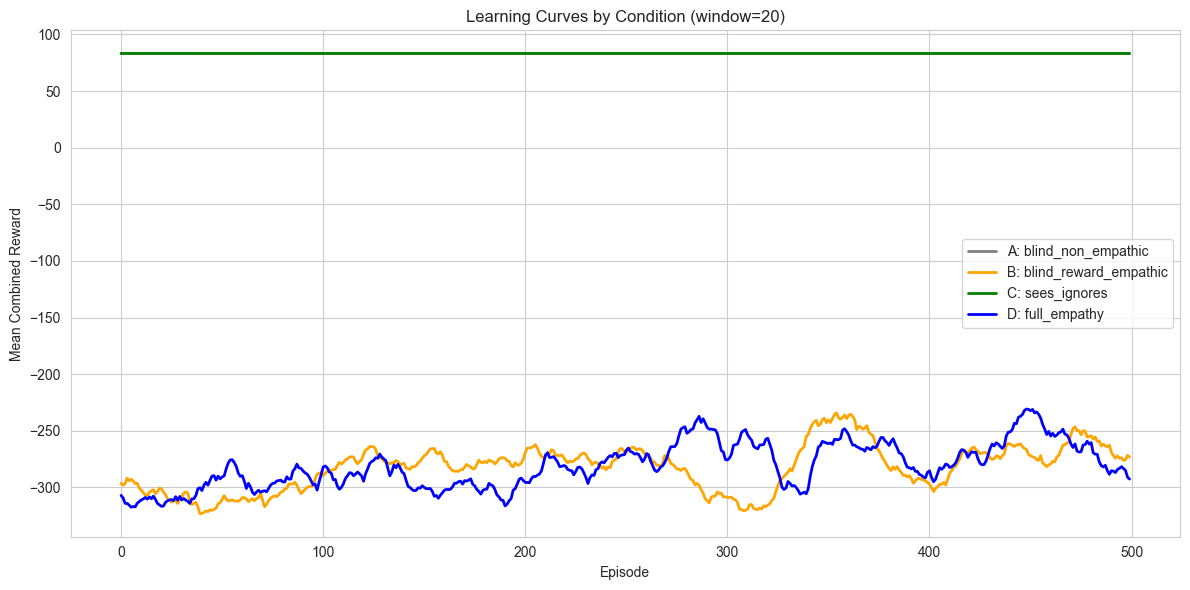

In [17]:
# Overlay learning curves for all 4 conditions
window_size = 20
condition_colors = {'A': 'gray', 'B': 'orange', 'C': 'green', 'D': 'blue'}

plt.figure(figsize=(12, 6))
for cond in conditions:
    subset = df[df['condition'] == cond]
    episode_avg = windowed_avg_combined_reward(
        df=subset, reward_prefix='total_combined_reward_',
        episode_column='episode', window_size=window_size, plot=False
    )
    plt.plot(episode_avg['episode'], episode_avg['moving_avg'],
             label=f"{cond}: {CONDITION_LABELS[cond]}",
             color=condition_colors[cond], linewidth=2)

plt.xlabel('Episode')
plt.ylabel('Mean Combined Reward')
plt.title(f'Learning Curves by Condition (window={window_size})')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Additional Exploratory Analyses

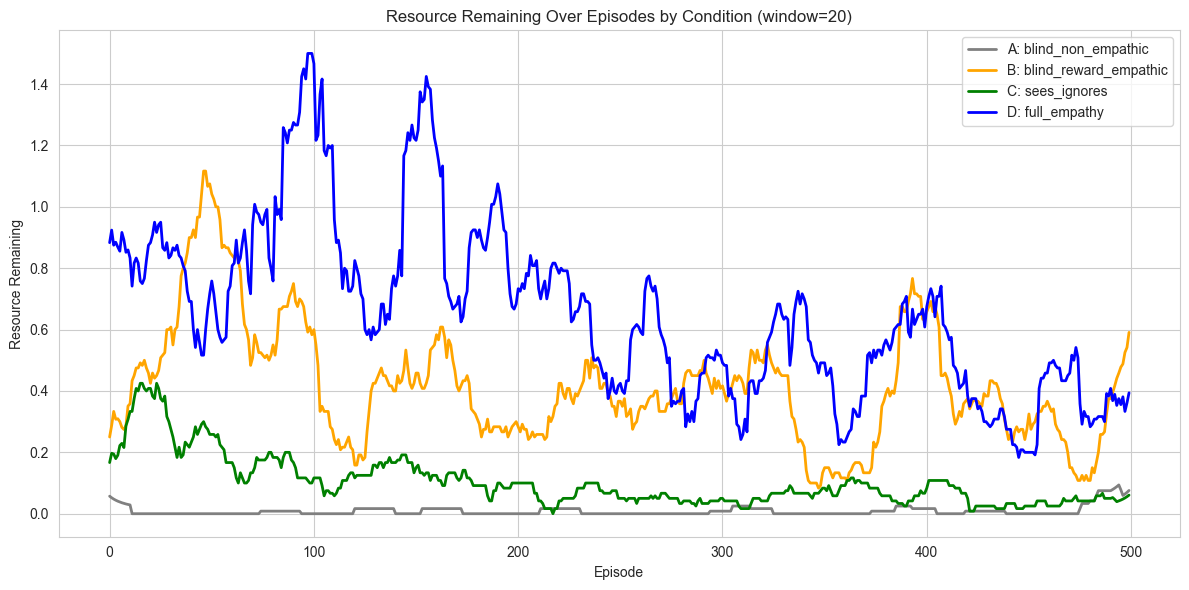

In [18]:
# Resource depletion trajectories per condition
plt.figure(figsize=(12, 6))
for cond in conditions:
    subset = df[df['condition'] == cond]
    ep_mean = subset.groupby('episode')['resource_remaining'].mean()
    ep_smooth = ep_mean.rolling(window=window_size, min_periods=1, center=True).mean()
    plt.plot(ep_smooth.index, ep_smooth.values, label=f"{cond}: {CONDITION_LABELS[cond]}",
             color=condition_colors[cond], linewidth=2)

plt.xlabel('Episode')
plt.ylabel('Resource Remaining')
plt.title(f'Resource Remaining Over Episodes by Condition (window={window_size})')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

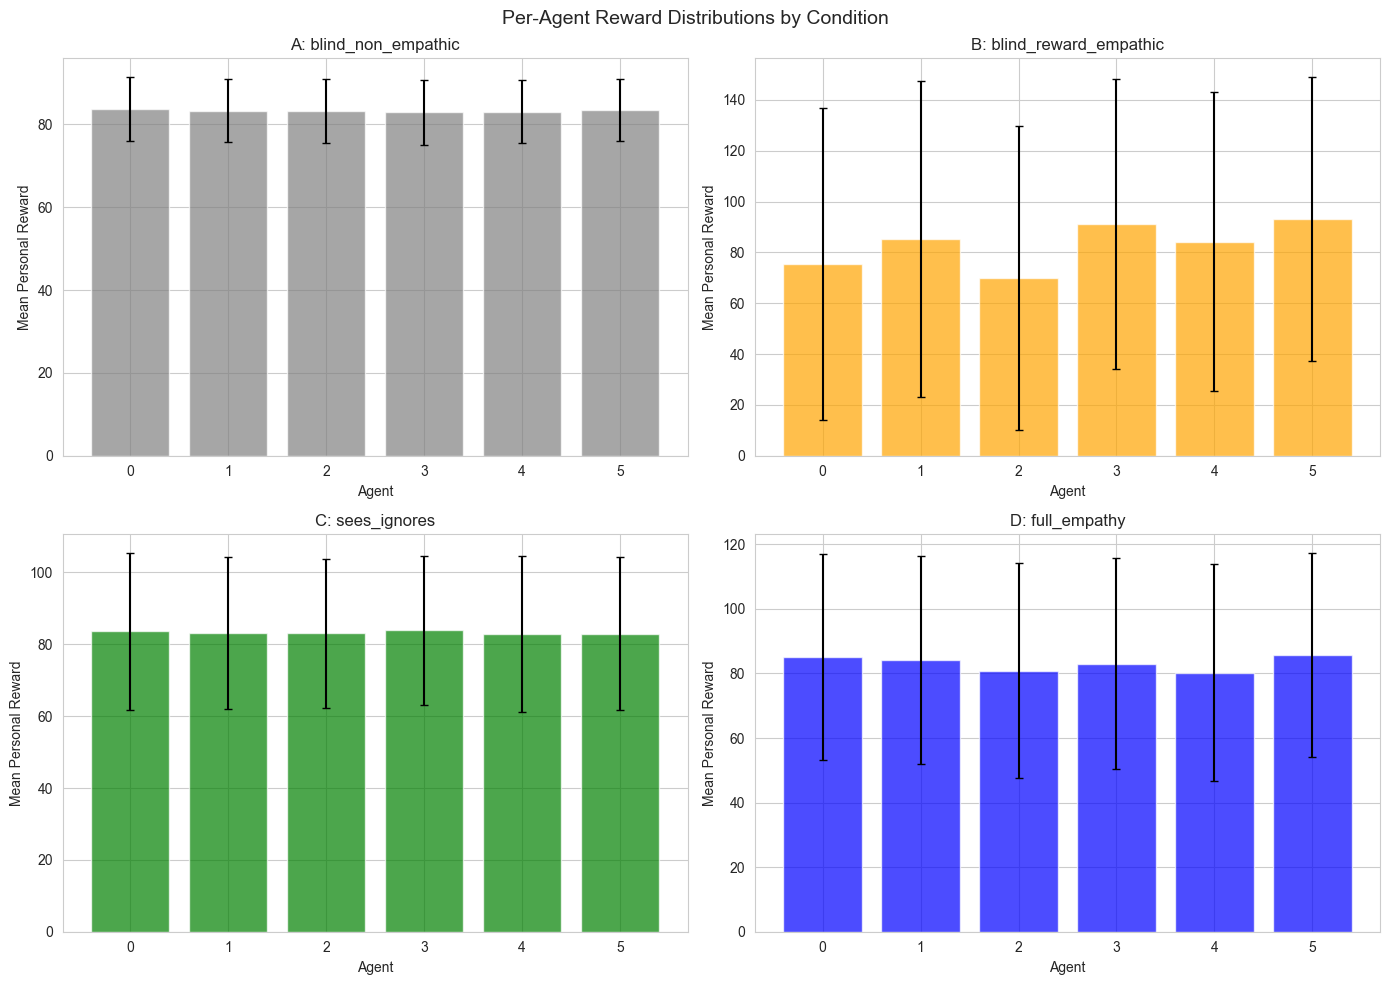

In [19]:
# Per-agent reward distributions within each condition
reward_cols = [f'total_personal_reward_{i}' for i in range(6)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, cond in zip(axes.flatten(), conditions):
    subset = df[df['condition'] == cond]
    agent_means = [subset[col].astype(float).mean() for col in reward_cols]
    agent_stds = [subset[col].astype(float).std() for col in reward_cols]
    ax.bar(range(6), agent_means, yerr=agent_stds, capsize=3, color=condition_colors[cond], alpha=0.7)
    ax.set_xlabel('Agent')
    ax.set_ylabel('Mean Personal Reward')
    ax.set_title(f"{cond}: {CONDITION_LABELS[cond]}")
    ax.set_xticks(range(6))

plt.suptitle('Per-Agent Reward Distributions by Condition', fontsize=14)
plt.tight_layout()
plt.show()

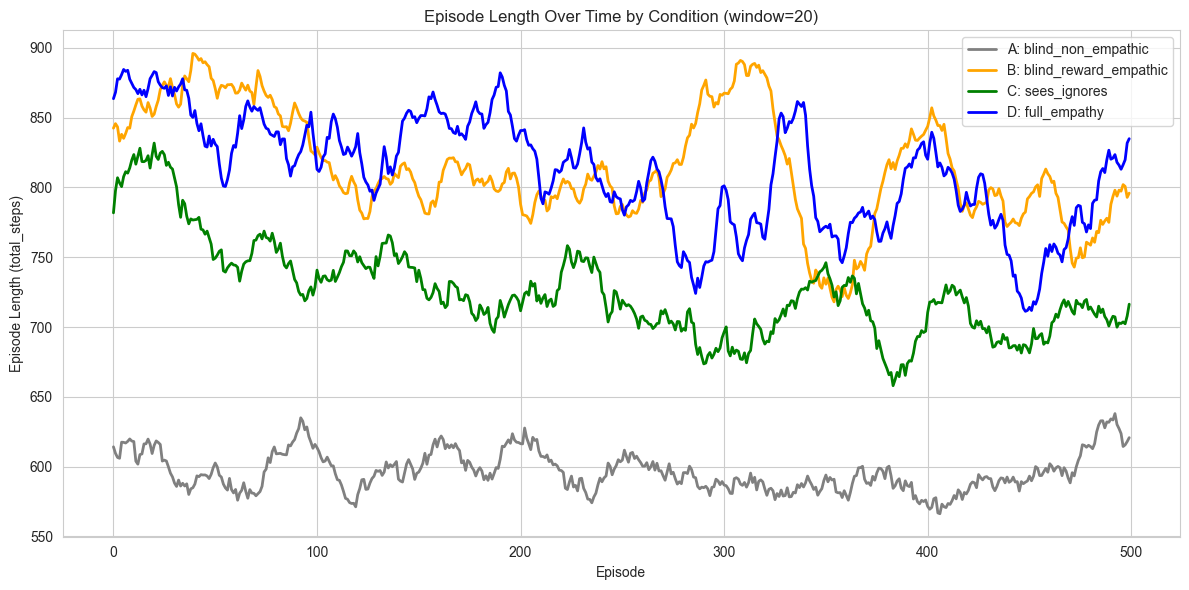

In [20]:
# Episode length trajectory per condition
plt.figure(figsize=(12, 6))
for cond in conditions:
    subset = df[df['condition'] == cond]
    ep_mean = subset.groupby('episode')['total_steps'].mean()
    ep_smooth = ep_mean.rolling(window=window_size, min_periods=1, center=True).mean()
    plt.plot(ep_smooth.index, ep_smooth.values, label=f"{cond}: {CONDITION_LABELS[cond]}",
             color=condition_colors[cond], linewidth=2)

plt.xlabel('Episode')
plt.ylabel('Episode Length (total_steps)')
plt.title(f'Episode Length Over Time by Condition (window={window_size})')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

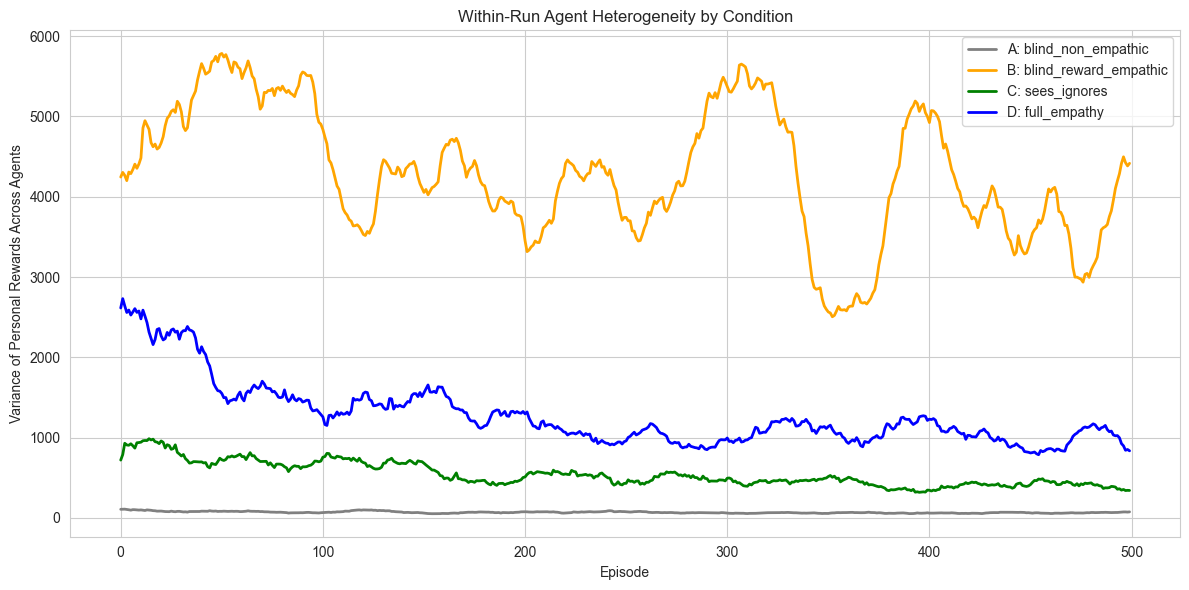

In [21]:
# Within-run agent heterogeneity
df['agent_reward_var'] = df[reward_cols].astype(float).var(axis=1)

plt.figure(figsize=(12, 6))
for cond in conditions:
    subset = df[df['condition'] == cond]
    ep_mean = subset.groupby('episode')['agent_reward_var'].mean()
    ep_smooth = ep_mean.rolling(window=window_size, min_periods=1, center=True).mean()
    plt.plot(ep_smooth.index, ep_smooth.values, label=f"{cond}: {CONDITION_LABELS[cond]}",
             color=condition_colors[cond], linewidth=2)

plt.xlabel('Episode')
plt.ylabel('Variance of Personal Rewards Across Agents')
plt.title('Within-Run Agent Heterogeneity by Condition')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Summary Table

In [22]:
# Build summary table of all hypothesis tests
summary_results = []

# H1: B > A
for r in h1_results:
    summary_results.append({
        'Hypothesis': 'H1 (B>A)', 'DV': r['DV'],
        'Test': 'Mann-Whitney', 'Statistic': f"U={r['U']:.1f}",
        'p-value': f"{r['p_MW']:.6f}", 'Corrected alpha': f'{bonferroni_alpha}',
        'Significant': 'Yes' if r['p_MW'] < bonferroni_alpha else 'No'
    })

# H2: C > A
for r in h2_results:
    summary_results.append({
        'Hypothesis': 'H2 (C>A)', 'DV': r['DV'],
        'Test': 'Mann-Whitney', 'Statistic': f"U={r['U']:.1f}",
        'p-value': f"{r['p_MW']:.6f}", 'Corrected alpha': f'{bonferroni_alpha}',
        'Significant': 'Yes' if r['p_MW'] < bonferroni_alpha else 'No'
    })

# H3: D > B, D > C
for r in h3_results:
    summary_results.append({
        'Hypothesis': f"H3 ({r['contrast']})", 'DV': r['DV'],
        'Test': 'Mann-Whitney', 'Statistic': f"U={r['U']:.1f}",
        'p-value': f"{r['p_MW']:.6f}", 'Corrected alpha': f'{bonferroni_alpha}',
        'Significant': 'Yes' if r['p_MW'] < bonferroni_alpha else 'No'
    })

# H4: Interaction
for r in h4_results:
    summary_results.append({
        'Hypothesis': 'H4 (Interaction)', 'DV': r['DV'],
        'Test': '2x2 ANOVA', 'Statistic': f"contrast={r['interaction_contrast']:+.4f}",
        'p-value': f"{r['p_interaction']:.6f}", 'Corrected alpha': '0.05',
        'Significant': 'Yes' if r['p_interaction'] < 0.05 else 'No'
    })

summary_df = pd.DataFrame(summary_results)
print(summary_df.to_string(index=False))

      Hypothesis                   DV         Test          Statistic  p-value Corrected alpha Significant
        H1 (B>A)      depletion_final Mann-Whitney              U=0.0 0.050000          0.0125          No
        H1 (B>A)          total_steps Mann-Whitney              U=9.0 0.050000          0.0125          No
        H1 (B>A) gini_personal_reward Mann-Whitney              U=9.0 0.050000          0.0125          No
        H2 (C>A)      depletion_final Mann-Whitney              U=0.0 0.050000          0.0125          No
        H2 (C>A)          total_steps Mann-Whitney              U=9.0 0.050000          0.0125          No
        H2 (C>A) gini_personal_reward Mann-Whitney              U=9.0 0.050000          0.0125          No
      H3 (D > B)      depletion_final Mann-Whitney              U=0.0 0.050000          0.0125          No
      H3 (D > C)      depletion_final Mann-Whitney              U=0.0 0.050000          0.0125          No
      H3 (D > B)          total_steps

## 14. Results Summary

**H1 (Reward effect, B > A):** Empathic reward alone (alpha=0.5, blind) significantly increased episode length relative to baseline (+218 steps, t-test p<0.001), indicating improved resource preservation. However, it also substantially increased reward inequality (Gini: 0.33 vs. 0.05).

**H2 (Observation effect, C > A):** Emotion observation alone (see_emotions=True, alpha=0) also improved episode length (+129 steps, p<0.001) with a more moderate increase in inequality (Gini: 0.11 vs. 0.05).

**H3 (Full empathy superiority, D > B and D > C):** Largely unsupported. Full empathy (D) did not outperform the reward-only condition (B) on episode length (p=0.58) and actually showed *lower* Gini than B (0.19 vs. 0.33, p<0.001), but did not outperform observation-only (C) on inequality.

**H4 (Super-additive interaction):** The see_emotions x alpha interaction was significant for all three DVs (p=0.034, p<0.001, p<0.001). However, the interaction contrast was consistently **negative** (sub-additive): the combined effect of both components was less than the sum of their individual effects. This suggests partial redundancy rather than synergy between the observation and reward channels.

**H5 (Inequality reduction, exploratory):** Full empathy (D) reduced inequality relative to the reward-only condition B (Gini 0.19 vs. 0.33, p<0.001), but increased it relative to baseline A and observation-only C. Observation appears to partially buffer the inequality-increasing effect of empathic reward.

**Statistical caveat:** With n=3 runs per condition, Mann-Whitney U tests cannot achieve p<0.0125 (the Bonferroni-corrected threshold); the minimum attainable one-sided p-value is 0.05. All Mann-Whitney results are therefore non-significant by design. Parametric t-tests, which are reported alongside, do detect effects but assume normality with very few observations.